EXERCICE 2 : Diagnostic complet d'un modèle — Résidus, Calibration, Lift, SHAP
================================================================================
Objectif : Réaliser un diagnostic complet d'un modèle de tarification
(analyse des résidus, courbe de lift, calibration, feature importance).

Ce que vous allez apprendre :
- Analyser les résidus par segment (âge, bonus-malus, région)
- Tracer et interpréter une courbe de lift
- Vérifier la calibration d'un modèle
- Interpréter les SHAP values

Pré-requis : M03_F01, M03_F05, Bloc 1-2 de ce module
Temps estimé : 15 minutes

In [13]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_poisson_deviance, make_scorer
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import lightgbm as lgb

## 1. DONNÉES ET MODÈLE

In [3]:
# =============================================================
# 1. DONNÉES ET MODÈLE
# # =============================================================
print("=" * 60)
print("EXERCICE 2 : Diagnostic complet d'un modèle")
print("=" * 60)

df = pd.read_csv("../M03_F01_Machine_Learning_Fondamentaux/freMTPL2freq.csv")
features = ['DrivAge', 'BonusMalus', 'VehAge', 'Density']
X = df[features].astype(float)
y = df['ClaimNb'].astype(float)
exposure = df['Exposure'].astype(float)

X_train, X_test, y_train, y_test, exp_train, exp_test = train_test_split(
    X, y, exposure, test_size=0.3, random_state=42
)
freq_train = y_train / exp_train
freq_test = y_test / exp_test

# Entraîner un LightGBM
model = lgb.LGBMRegressor(
    objective='poisson', n_estimators=300, learning_rate=0.05,
    num_leaves=31, random_state=42, verbose=-1
)
model.fit(X_train, freq_train, sample_weight=exp_train)
freq_pred = np.clip(model.predict(X_test), 1e-6, None)

print(f"Poisson Deviance : {mean_poisson_deviance(freq_test, freq_pred, sample_weight=exp_test):.6f}")

EXERCICE 2 : Diagnostic complet d'un modèle


Exception in thread Thread-4 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\U011513\.pyenv\pyenv-win\versions\3.13.1\Lib\threading.py", line 1041, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "c:\Users\U011513\.pyenv\pyenv-win\versions\3.13.1\Lib\threading.py", line 992, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\U011513\.pyenv\pyenv-win\versions\3.13.1\Lib\subprocess.py", line 1609, in _readerthread
    buffer.append(fh.read())
                  ~~~~~~~^^
  File "<frozen codecs>", line 325, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xae in position 13: invalid start byte


Poisson Deviance : 0.584657



PARTIE 1 : Analyse des résidus


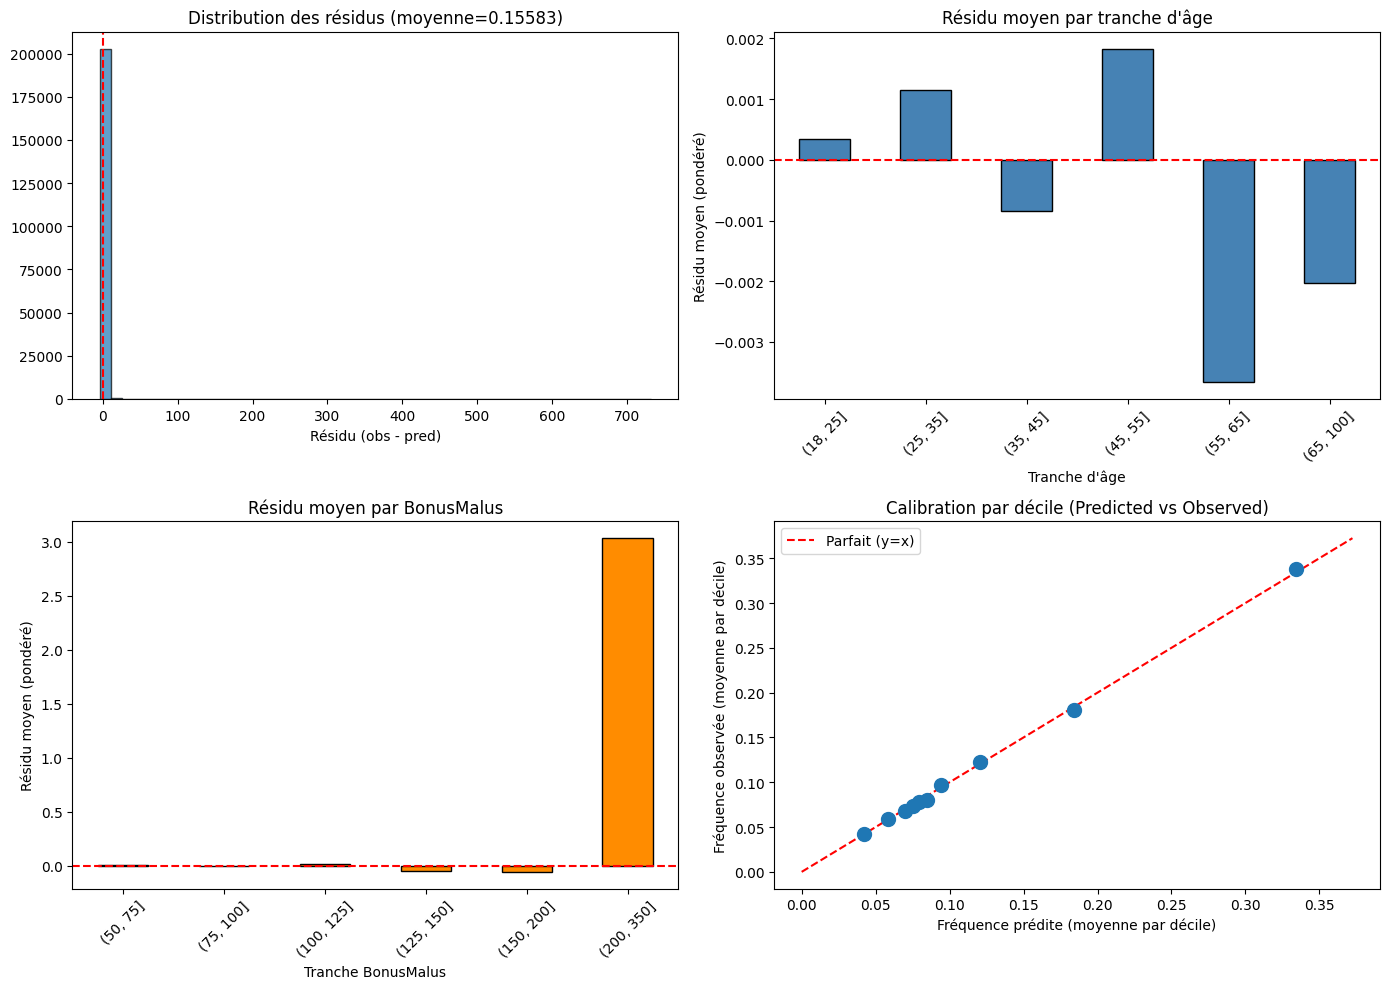

Résidu moyen global : 0.155830

Résidus par âge :
age_bin
(18, 25]     0.00034
(25, 35]     0.00115
(35, 45]    -0.00084
(45, 55]     0.00183
(55, 65]    -0.00366
(65, 100]   -0.00202
dtype: float64


In [ ]:
# =============================================================
# 2. ANALYSE DES RÉSIDUS
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 1 : Analyse des résidus")
print("=" * 60)

# Résidus = fréquence observée - fréquence prédite
residuals = freq_test - freq_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# TODO : Tracer la distribution des résidus (histogramme)
# Le résidu moyen devrait être proche de 0 (pas de biais systématique)


# TODO : Tracer les résidus moyens par tranche d'âge du conducteur
# Créer des tranches : [18-25], [25-35], [35-45], [45-55], [55-65], [65+]
# Si les résidus ne sont pas plats → le modèle a un biais sur ce segment
# Indice : pd.cut(X_test['DrivAge'], bins=[18, 25, 35, 45, 55, 65, 100])


# TODO : Tracer les résidus moyens par tranche de BonusMalus
# bins=[50, 75, 100, 125, 150, 200, 350]
# TODO : Tracer predicted vs observed (scatter plot)
# Si parfait : tous les points sur la diagonale



PARTIE 2 : Courbe de lift

Table de lift :
decile  n_contracts  freq_obs  mean_pred     lift
     1        20341  0.042423   0.042476 0.422386
     2        20340  0.059039   0.058170 0.587824
     3        20340  0.068274   0.070051 0.679774
     4        20371  0.074015   0.075116 0.736938
     5        20314  0.077573   0.079365 0.772360
     6        20339  0.080444   0.084560 0.800948
     7        20339  0.096639   0.094439 0.962193
     8        20339  0.122446   0.120324 1.219147
     9        20341  0.180353   0.184370 1.795703
    10        20340  0.338484   0.334184 3.370146


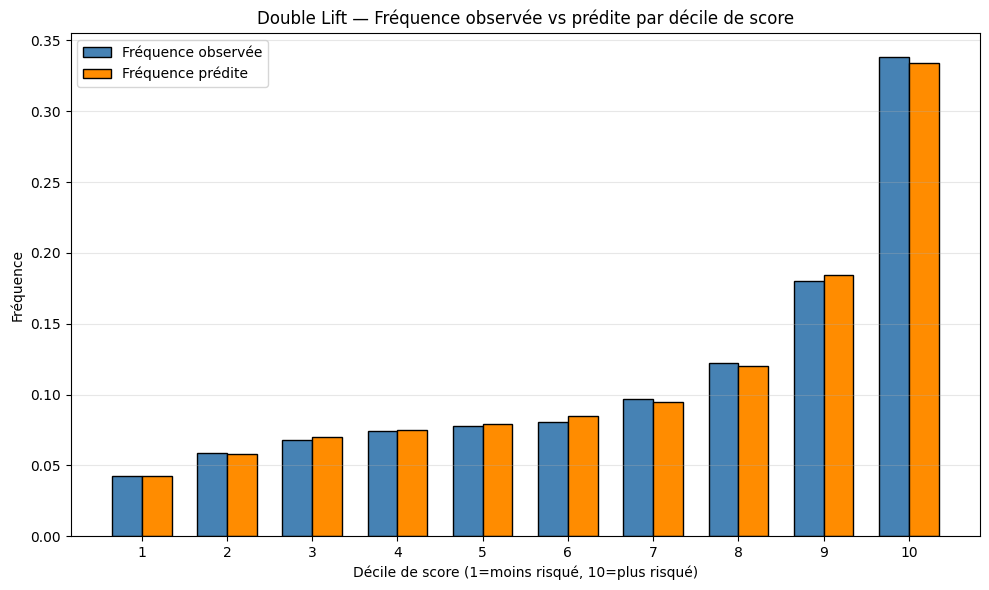

In [ ]:
# =============================================================
# 3. COURBE DE LIFT
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 2 : Courbe de lift")
print("=" * 60)

# La courbe de lift montre le pouvoir discriminant du modèle :
# on trie les assurés par score prédit (du plus risqué au moins risqué)
# et on regarde si les "vrais" sinistres sont bien concentrés en haut

# TODO : Trier les observations par fréquence prédite décroissante
# Créer 10 déciles de score
# Pour chaque décile, calculer la fréquence observée et prédite

# Indice :
# df_test = pd.DataFrame({'freq_pred': freq_pred, 'freq_obs': freq_test, 'exposure': exp_test})
# df_test['decile'] = pd.qcut(df_test['freq_pred'], 10, labels=False)
# lift_table = df_test.groupby('decile').agg(...)



# TODO : Tracer le "double lift" : fréquence observée et prédite par décile
# Un bon modèle : les déciles à haut score ont une fréquence observée élevée


PARTIE 3 : Courbe de Lorenz et coefficient de Gini


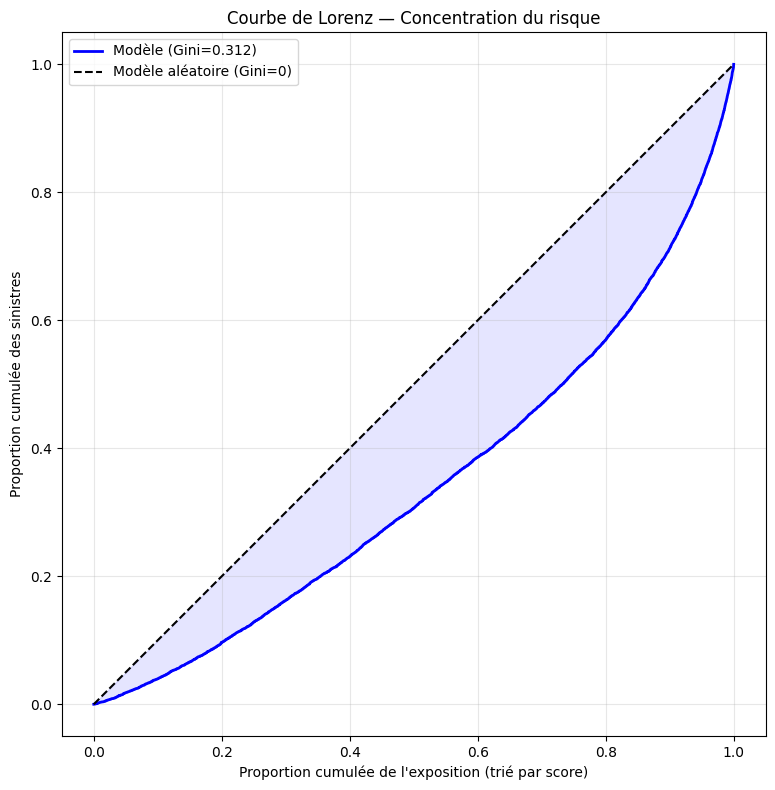

Coefficient de Gini : 0.3123


In [ ]:
# =============================================================
# 4. COURBE DE LORENZ ET GINI
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 3 : Courbe de Lorenz et coefficient de Gini")
print("=" * 60)

# TODO : Construire la courbe de Lorenz ordonnée par le score du modèle
# Principe :
# 1. Trier les assurés par score prédit (croissant)
# 2. Calculer la proportion cumulée de l'exposition
# 3. Calculer la proportion cumulée des sinistres
# 4. Tracer l'un contre l'autre

# Indice :
# sorted_idx = np.argsort(freq_pred)
# cum_exposure = np.cumsum(exp_test.values[sorted_idx]) / exp_test.sum()
# cum_claims = np.cumsum(y_test.values[sorted_idx]) / y_test.sum()




# TODO : Calculer le Gini = 2 * (aire sous Lorenz - 0.5)
# Comparer avec le Gini théorique = 2*AUC - 1
# Ici on trie du moins risqué au plus risqué → Lorenz est en dessous de la diagonale



PARTIE 4 : Feature importance et SHAP

Comparaison des importances :
            Impurity (split)  Permutation
VehAge                0.2114       0.6402
BonusMalus            0.2066       0.2099
DrivAge               0.2869       0.0865
Density               0.2951       0.0634


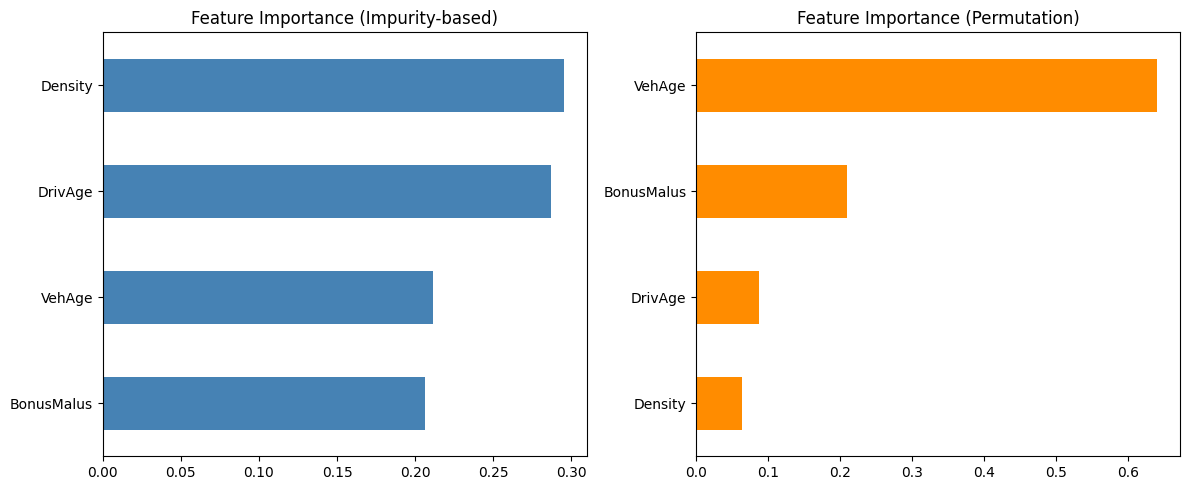


→ shap non installé. pip install shap pour les SHAP values.


In [ ]:
# =============================================================
# 5. FEATURE IMPORTANCE (SHAP)
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 4 : Feature importance et SHAP")
print("=" * 60)

# TODO : Afficher la feature importance du LightGBM (impurity-based)
# Indice : model.feature_importances_
# Impurity-based



# TODO : Calculer la permutation importance (plus fiable)
# Indice : from sklearn.inspection import permutation_importance
#           result = permutation_importance(model, X_test, freq_test, 
#                    n_repeats=10, scoring=scorer, random_state=42)


c:\Users\U011513\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



--- SHAP values ---


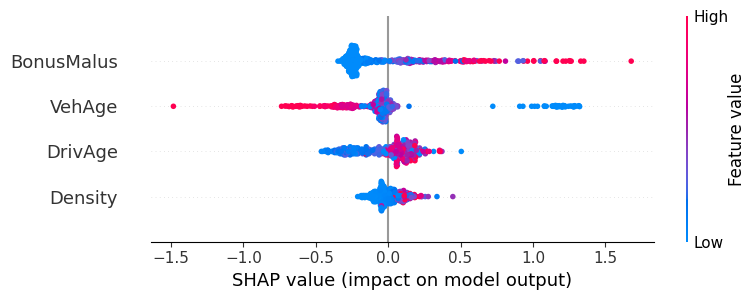

→ SHAP summary plot sauvegardé


In [ ]:
# TODO (BONUS) : Si shap est installé, calculer et afficher les SHAP values
# Indice :
#   import shap
#   explainer = shap.TreeExplainer(model)
#   shap_values = explainer.shap_values(X_test.iloc[:500])
#   shap.summary_plot(shap_values, X_test.iloc[:500])
# SHAP (optionnel)
try:
    import shap
    print("\n--- SHAP values ---")
except ImportError:
    print("\n→ shap non installé. pip install shap pour les SHAP values.")


## INTERPRÉTATION DES SHAP VALUES

### Interprétation du SHAP Summary Plot
- **Axe X** : Valeur SHAP (impact sur la sortie du modèle)
  - Négatif = la variable *réduit* la fréquence prédite
  - Positif = la variable *augmente* la fréquence prédite
- **Couleur** : Valeur de la variable
  - Bleu = valeur basse de la variable
  - Rouge = valeur haute de la variable
- **Position (Y)** : Importance globale (variables les plus importantes en haut)

### Insights clés du plot affiché
1. **BonusMalus** (en haut) : Variable la plus importante
   - Points rouges (BM élevé) dispersés à droite (+) → Coefficient élevé augmente la fréquence
   - Points bleus (BM bas) dispersés à gauche (-) → Bon client réduit la fréquence
   - Effet très asymétrique : les mauvais clients (BM > 100) font beaucoup monter le risque

2. **DrivAge** : Effet non-monotone
   - Les conducteurs jeunes (bleu) dispersés à droite : âge bas = fréquence haute
   - Les conducteurs âgés (rouge) également dispersés : courbe d'âge en U typique

3. **VehAge** et **Density** : Effets secondaires
   - Contribution plus modérée au modèle
   - À interpréter en fonction de votre secteur


In [ ]:
# =============================================================
# QUESTIONS DE RÉFLEXION
# =============================================================
"""
1. Les résidus sont-ils symétriques autour de 0 ? Sinon, pourquoi ?
   (Indice : nature des données de fréquence sinistre)

2. Y a-t-il des segments d'âge où le modèle est systématiquement biaisé ?
   Que feriez-vous pour corriger ce biais ?

3. La courbe de lift est-elle monotone (déciles hauts = fréquence haute) ?
   Que signifierait un "croisement" entre les déciles ?

4. Quel est le Gini de votre modèle ? Comparez-le aux standards du marché
   en tarification auto (typiquement 0.25-0.40 en fréquence).

5. Les feature importances (impurity vs permutation) sont-elles cohérentes ?
   Si non, laquelle est la plus fiable et pourquoi ?

6. Si vous utilisiez SHAP : quelle variable a le plus grand impact positif 
   sur la fréquence prédite ? Est-ce cohérent avec votre expertise actuarielle ?
"""